In [ ]:
# You will need numpy, xarray and netcdf4 packages to run this
import numpy as np
import xarray as xr
from matplotlib import pyplot as plt

In [2]:
gaia_data = xr.load_dataset("./gaia-dr3.nc")

# Inspecting data
gaia_data

<xarray.Dataset> Size: 24MB
Dimensions:         (number: 60517, wl: 16, snr_thresh: 7, pc: 5)
Coordinates:
  * number          (number) int32 242kB 1 2 3 4 ... 399322 399523 399606 399767
  * wl              (wl) float32 64B 0.374 0.418 0.462 ... 0.946 0.99 1.034
  * snr_thresh      (snr_thresh) int64 56B 0 20 30 40 50 75 100
  * pc              (pc) int64 40B 0 1 2 3 4
Data variables:
    refl            (number, wl) float32 4MB 0.8179 0.8912 ... 1.179 2.064
    unc             (number, wl) float32 4MB 0.0004573 0.0003498 ... 0.1921
    mask            (number, wl) bool 968kB False False False ... True False
    data_flags      (number, wl) int16 2MB 0 0 0 0 0 0 2 1 0 ... 0 0 0 0 0 0 1 0
    snr             (number) float32 242kB 2.593e+03 3.841e+03 ... 17.42 22.75
    spectral_slope  (number) float64 484kB 2.409 0.1396 10.85 ... 4.069 14.39
    z-i             (number) float64 484kB 0.01147 -0.01774 ... 0.08943 0.03307
    pca_vals        (snr_thresh, pc, number) float32 8MB -0.3751 ... 0.01362
    interp_refl     (number, wl) float32 4MB 0.8179 0.8912 ... 1.554 2.064

In [15]:
# Example of retrieving masked spectra
numbers = [1003, 1004, 1005, 1006, 1007]  # asteroid numbers to get the spectra for
wl = gaia_data.wl.values
refl = gaia_data.sel(number=numbers).refl.values    # reflectance values are normalized at 0.55 microns
unc = gaia_data.sel(number=numbers).unc.values
mask = gaia_data.sel(number=numbers).mask.values # remember that the mask is False for good data and True for bad data

refl_masked = np.ma.array(refl, mask=mask, fill_value=np.nan)
unc_masked = np.ma.array(unc, mask=mask, fill_value=np.nan)

Text(0, 0.5, 'Reflectance')

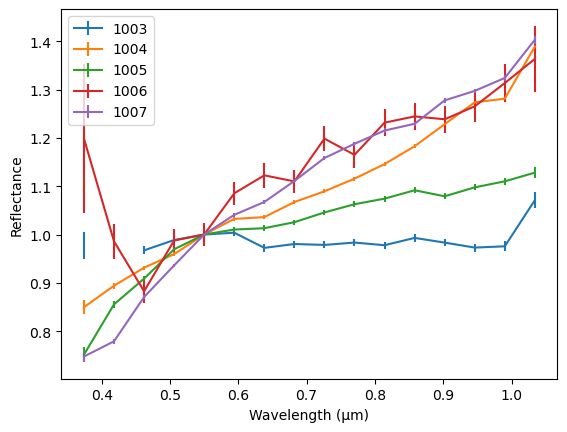

In [17]:
# Looking at the spectra
fig, ax = plt.subplots()
for i, number in enumerate(numbers):
    ax.errorbar(wl, refl_masked[i], yerr=unc_masked[i], label=f"{number}")

ax.legend()
ax.set_xlabel("Wavelength (µm)")
ax.set_ylabel("Reflectance")